# Information Theory and Inference - Assignment 6

Gabriel Amorosetti - Matricola N. 2107530

---------

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

The file ('Data for exercise 6') contains data sampled from a mixture of $K = 4$ Gaussians. The standard deviations of the Gaussians are known and identical, $\sigma_k = \sigma = 0.5$. 

Reconstruct the unknown parameters and latent variables, $p_k, \mu_k, Z_i$, where $Z_i$ represents the assignment of each point to one of the mixture components.

In [2]:
# importing the data and printing the first 10 values

data = np.loadtxt('4Gaussians.txt')  
print(data[:10])

[0.50724463 6.86411422 3.68379862 0.2640825  7.10858982 7.03910559
 7.70227276 7.07322039 3.51720494 6.25937702]


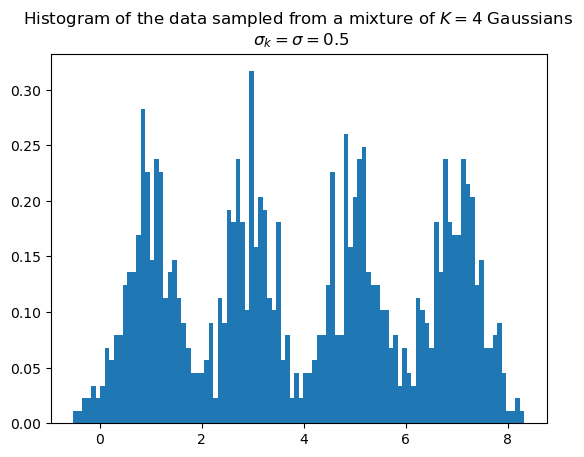

In [3]:
# Histogram of the data, representing the mixture of 4 gaussians

plt.figure()
plt.hist(data, bins = 100, density = True)
plt.title("Histogram of the data sampled from a mixture of $K = 4$ Gaussians \n $\sigma_k = \sigma = 0.5$")
plt.show()

 To perform the inference, use Gibbs sampling :

* Initialize randomly $p_k, \mu_k, Z_i$. 
  
  Compute 
    - $N_k = \sum_i \chi(Z_i = k)$, 
    - $m_k = \sum_i \chi(Z_i = k)x_k$.

* Perform Gibbs sampling iterations

    - Sample $\mu_k$ from a normal with mean $\mu'_k = \left(\dfrac{\mu_0}{\sigma_0^2} + \dfrac{m_k}{\sigma^2}\right) \dfrac{1}{\left(\dfrac{1}{\sigma_0^2} + \dfrac{N_k}{\sigma^2}\right)}$ and std. dev. $\sigma'_k = \left(\dfrac{1}{\sigma_0^2} + \dfrac{N_k}{\sigma^2}\right)^{-1/2}$. 
  
        Here $\mu_0 = 0$ and $\sigma_0 = 1000$ are the Gaussian prior parameters. 
        
        Do this for all $k$.
 
    - Sample the $p$ from a Dirichlet distribution with parameters $\gamma'_k = \gamma_k + N_k$. 
        Here, $\gamma_k = 1$ are the Dirichlet prior parameters.

    - Sample the $Z_i$ from a categorical distribution, 
        
        $Prob(Z_i = k) = \dfrac{p_k e^{-\dfrac{(x_k - \mu_k)^2}{2\sigma^2}}}{\sum_k p_k e^{-\dfrac{(x_k - \mu_k)^2}{2\sigma^2}}}$


    If $Z_i$ is updated, update $N_k, m_k$.

In [4]:
K = 4               # number of gaussians in the mixture (clusters)
N = len(data)       # number of data points
sigma = 0.5         # standard deviation and its squared value
sigma_2 = sigma**2



# Priors from the assignment :
mu_0 = 0
sigma_0 = 1000
sigma_0_2 = sigma_0**2
gamma_k = 1       



# initializating randomly pk​,μk​,Zi​ :

Z = np.random.randint(0, K, size=N) # randomly assigning every point to a cluster

mu = np.random.uniform(min(data), max(data), size=K) # initializing means randomly (between min and max of the data)

p = np.ones(K) / K # initializing the weights uniformly (all equals)



# initializing N_k and m_k : 

# N_k = how many points in cluster k
# m_k is the sum of values of points in cluster k

N_k = np.zeros(K)
m_k = np.zeros(K)

for k in range(K) :
    points_in_k = data[Z == k]     # points currently assigned to cluster k
    N_k[k] = len(points_in_k)      # counting how many they are 
    m_k[k] = np.sum(points_in_k)   # sum of their values




# Gibbs iterations : 

iterations = 3000  
trace_mu = []      # to store history of the value of mu for plotting

print("Starting Gibbs sampling")

for it in range(iterations) :
    
    # sampling the means (mu_k)
    for k in range(K) :

        # using mu_k' formula, step by step
        precision_0 = 1 / sigma_0_2
        precision_data = N_k[k] / sigma_2

        denom = precision_0 + precision_data
        numer = (mu_0 / sigma_0_2) + (m_k[k] / sigma_2)

        mu_prime = numer / denom
        
        # the posterior standard deviation
        sigma_prime = np.sqrt(1 / denom)
        
        # sampling new mu_k from this new normal distrib
        mu[k] = np.random.normal(mu_prime, sigma_prime)
        

    # sampling the weights (p) :

    # Dirichlet parameters list : prior (gamma) + counts (N_k), ie [1+N_0, 1+N_1, 1+N_2, 1+N_3]
    gamma_prime = [gamma_k + count for count in N_k]

    # sampling from Dirichlet
    p = np.random.dirichlet(gamma_prime)
    

    # sampling assignments (Z_i) :

    # looping through every data point
    for i in range(N) :
        x_val = data[i]
        old_k = Z[i]
        
        # first we remove this point from the stats N_k and m_k
        # because the assignment probability shouldn't include itself
        N_k[old_k] -= 1
        m_k[old_k] -= x_val
        
        # then we compute the probability of belonging to each cluster k
        probs = np.zeros(K)
        for k in range(K) :
            # likelihood : Gaussian PDF
            likelihood = np.exp(- (x_val - mu[k])**2 / (2 * sigma_2)) # proba that x_val comes from the mean mu[k]
            # multipliying by the weight of the cluster
            probs[k] = p[k] * likelihood
            
        # normalizing probas so the sum is 1
        if np.sum(probs) > 0 :
            probs = probs / np.sum(probs)
        # else : # in case of numerical issues
        #     probs = np.ones(K) / K
            
        # new label for this point and updating it
        new_k = np.random.choice(range(K), p = probs)
        Z[i] = new_k
        
        # finally updating the stats 
        N_k[new_k] += 1
        m_k[new_k] += x_val

    # storing mu for the plot
    trace_mu.append(mu.copy())
    
    # giving some updates when iterating
    if it % 100 == 0 :
        print(f"Iteration {it} : {K} means = {np.round(mu, 2)}")

print("\ndone")
print(f"Final estimated {K} means: {np.round(np.sort(mu), 3)}")
print(f"Final estimated {K} weights: {np.round(p[np.argsort(mu)], 3)}")


Starting Gibbs sampling
Iteration 0 : 4 means = [4.11 3.67 4.   4.03]
Iteration 100 : 4 means = [7.03 0.88 2.91 5.03]
Iteration 200 : 4 means = [7.1  0.95 3.   5.08]
Iteration 300 : 4 means = [7.03 0.92 2.92 4.99]
Iteration 400 : 4 means = [7.02 0.93 2.93 5.03]
Iteration 500 : 4 means = [6.95 0.9  2.87 4.92]
Iteration 600 : 4 means = [6.99 0.93 2.9  4.93]
Iteration 700 : 4 means = [7.05 0.97 2.98 5.02]
Iteration 800 : 4 means = [7.02 0.92 2.99 4.98]
Iteration 900 : 4 means = [7.01 0.91 2.98 5.  ]
Iteration 1000 : 4 means = [7.03 0.93 2.95 5.03]
Iteration 1100 : 4 means = [6.96 0.96 2.92 4.97]
Iteration 1200 : 4 means = [7.06 0.96 2.97 5.03]
Iteration 1300 : 4 means = [6.98 0.9  2.92 4.93]
Iteration 1400 : 4 means = [6.96 0.94 2.9  4.99]
Iteration 1500 : 4 means = [7.01 0.97 2.95 5.  ]
Iteration 1600 : 4 means = [7.03 0.96 2.92 5.02]
Iteration 1700 : 4 means = [7.01 0.91 2.94 4.99]
Iteration 1800 : 4 means = [7.05 0.95 2.93 5.06]
Iteration 1900 : 4 means = [6.98 0.91 2.91 4.98]
Iteratio

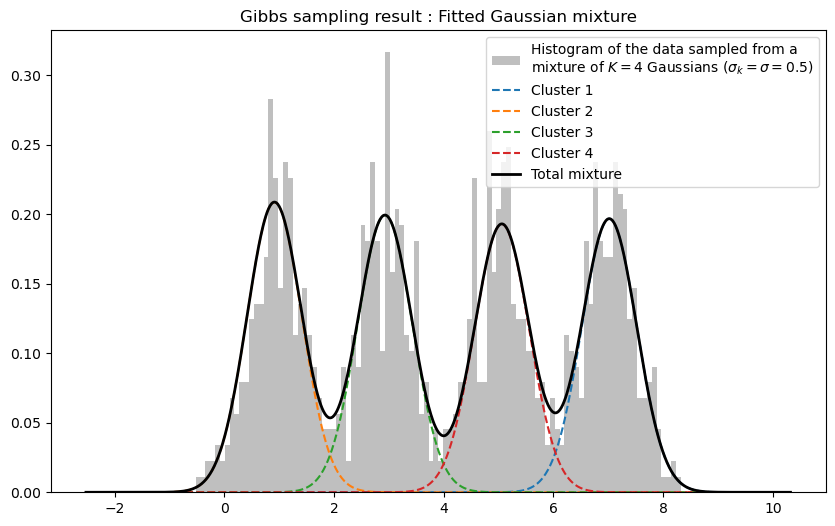

In [5]:
plt.figure(figsize=(10, 6))

# Plot histogram of original data
plt.hist(data, bins=100, density=True, alpha=0.5, color='gray', label='Histogram of the data sampled from a \nmixture of $K = 4$ Gaussians ($\sigma_k = \sigma = 0.5$)')


# Plot the final estimated Gaussians
x_axis = np.linspace(min(data)-2, max(data)+2, 1000)
total_pdf = np.zeros_like(x_axis)

# plotting each cluster gaussian
for k in range(K) :
    pdf = p[k] * norm.pdf(x_axis, mu[k], sigma)
    total_pdf += pdf
    plt.plot(x_axis, pdf, '--', label=f'Cluster {k+1}')

plt.plot(x_axis, total_pdf, 'k-', linewidth = 2, label='Total mixture')
plt.title('Gibbs sampling result : Fitted Gaussian mixture')
plt.legend()
plt.show()